# Resources , NOTE: Run on CPU else Errors, Big Problem PyTorch == Diff Device
## Documentation(replace with 2.12/2.13): https://docs.pytorch.org/docs/2.11/index.html
## Daniel Brourke: https://www.youtube.com/watch?v=Z_ikDlimN6A
## FreeCodeCamp: https://www.youtube.com/watch?v=vo_fUOk-IKk
## Patrick Loeber: https://www.youtube.com/playlist?list=PLqnslRFeH2UrcDBWF5mfPGpqQDSta6VK4
## Advance:: Aladdin Persson (GANs/Seq-to-Seq/Research): https://www.youtube.com/playlist?list=PLhhyoLH6IjfxeoooqP9rhU3HJIAVAJ3Vz

## CheatSheet: https://pytorch.org/tutorials/beginner/ptcheat.html

In [1]:
import torch
print(torch.__version__)
# Reproducibility (Random Seed setting)
# torch.cuda.manual_seed(42)
torch.manual_seed(42) # have to use it for each declaration of vars Like this ex
#tensor = torch.rand(2) # above works for this line only

2.10.0+cpu


In [2]:
# Using GPUs
# Step 1: download pytorch version as per device & cuda version
# Step 2: check and set the device var
torch.cuda.is_available()
torch.cuda.device_count()
device = "cuda" if torch.cuda.is_available() else "cpu"
device # make tensors with device=device

'cpu'

In [3]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [4]:
#scalar
scalar = torch.tensor(7)
scalar,
scalar.ndim, scalar.item()

(0, 7)

In [5]:
#vector
vector = torch.tensor([7,7])
#vector, vector.ndim, vector.shape
matrix = torch.tensor([[7,8],[9,10]])
matrix, matrix.ndim, matrix.shape

(tensor([[ 7,  8],
         [ 9, 10]]),
 2,
 torch.Size([2, 2]))

In [6]:
# TENSOR
TENSOR = torch.tensor([[[1,2,3],[3,6,9],[2,4,5]]])
TENSOR, TENSOR.ndim, TENSOR.shape

(tensor([[[1, 2, 3],
          [3, 6, 9],
          [2, 4, 5]]]),
 3,
 torch.Size([1, 3, 3]))

In [7]:
# Random, Zeros, Ones, Range Tensors
random_tensor = torch.rand(3,4,1) #row, col, 3th , 4th,...nth dim
image_tensor = torch.zeros(size=(244, 244, 3))#ht, wid, colr channel with 0 initVal
ones_tensor = torch.ones(2,3)
range_tensor = torch.arange(start=0, end=1000, step=50)
copy = torch.zeros_like(input=range_tensor)

# Restore the built-in range function in case it was overwritten
import builtins
range = builtins.range

random_tensor.device, image_tensor.shape, ones_tensor.dtype, range_tensor, copy

(device(type='cpu'),
 torch.Size([244, 244, 3]),
 torch.float32,
 tensor([  0,  50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650,
         700, 750, 800, 850, 900, 950]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

In [8]:
# Tensor DataType
#if error:
#1. not right Datatype  2. not right shape  3. not right device
float_tensor = torch.tensor([3.0, 6.0, 9.0],
                             dtype=torch.double, #None==torch.float==float32, torch.half==float16
                             device=device, # "cpu" / "cuda"
                             requires_grad=False) #whether to trach gradients or not with this tensor
int_tensor = float_tensor.type(torch.int32)

float_tensor.dtype, int_tensor.dtype, float_tensor.device

(torch.float64, torch.int32, device(type='cpu'))

In [9]:
# Operation / Manipulation : add, sub, mult, div, matmul, transpose

torch.add(int_tensor, 10) # int_tensor+10
torch.sub(int_tensor, float_tensor) # int_tensor-float_tensor
torch.mul(int_tensor, 10) # int_tensor*10 #element-wise
torch.divide(int_tensor, 10) # int_tensor/10
torch.matmul(int_tensor.float(), int_tensor.float()) # int_tensor @ int_tensor # torch.mm(t1,t2) #matmul & error if not using .float() on T4 GPU
int_tensor.T #transpose

/tmp/ipykernel_19894/3790521518.py:8: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  int_tensor.T #transpose


tensor([3, 6, 9], dtype=torch.int32)

In [10]:
# Tensor Aggregation: Min, Max, Mean, Sum etc.

int_tensor.min() # torch.min(int_tensor)
int_tensor.max() # torch.max(int_tensor)
int_tensor.type(torch.float32).mean() # torch.mean(int_tensor.type(torch.float32))
int_tensor.sum() # torch.sum(int_tensor)

# Finding Positional Min & Max i.e. position in tensor
int_tensor.argmin(), int_tensor.argmax(), int_tensor[2]

(tensor(0), tensor(2), tensor(9, dtype=torch.int32))

In [11]:
# Reshaping, View, Stacking, Squeezing, Unsqueezing, Permute Tensors

x = torch.arange(1., 10.)
x.shape
# Reshaping: the total elements should be same
x_reshaped = x.reshape(1, 9)
x_reshaped, x_reshaped.shape

# View
z = x.view(1, 9)
z, z.shape

# Stack: Vertically / horizontally stacking, vstack/hstack
x_stacked = torch.stack([x,x,x,x], dim=1)
x_stacked, x_stacked.shape

# Squeez: Same like tf removes single dims from tensor
# UnSqueez: Adds one dim to  a tensor  , do newtensr =
x_reshaped.squeeze().shape #[1,9] -> [9]
x_reshaped.unsqueeze(dim=0).shape #[9] -> [1,9]

# Permute: rearranges teh dims of a tensor as given as args
image_tensor.shape, image_tensor.permute(2,0,1).shape

(torch.Size([244, 244, 3]), torch.Size([3, 244, 244]))

In [12]:
# Indexing (selecing data from tensors: like numpy)
image_tensor[0][100][1] #it'll be zero coz initialied with zeros
image_tensor[:, :, 1] # all values of 1st and 2nd dim & 1 form 3rd dim

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [13]:
# Pytorch -> Numpy & Vice Versa
import torch
import numpy as np
arr = np.arange(1., 9.)
tn = torch.from_numpy(arr) # np -> torch
nparr = tn.numpy() # torch -> np

arr, tn, nparr

(array([1., 2., 3., 4., 5., 6., 7., 8.]),
 tensor([1., 2., 3., 4., 5., 6., 7., 8.], dtype=torch.float64),
 array([1., 2., 3., 4., 5., 6., 7., 8.]))

In [14]:
# WorkFlow
# DataSet Generation
import torch
from torch import nn
import matplotlib.pyplot as plt

wt ,bias = 0.7, 0.3

start , end , step = 0,1,0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = wt * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [15]:
from sklearn.model_selection import train_test_split

# do spliting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)

(40, 10, 40, 10)

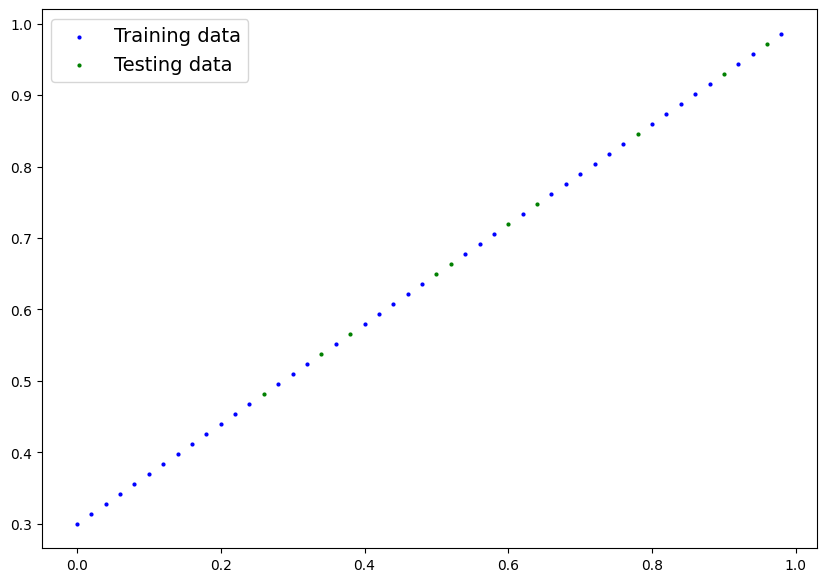

In [16]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plot training data, testing data nd compares predictions """
  plt.figure(figsize=(10, 7))
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
  plt.legend(prop={"size": 14})
plot_predictions()

In [17]:
# Build Model , we need wt, bias, optimizer, loss func
# torch.optim has optimizers for nn models, helping in gradient descnt
# torch.nn.L1Loss / MSELoss / CrossEntropyLoss / PoissonLoss etc.
# make training and testing loop
class LinearRegressionModel(nn.Module):
  """Linear Regression Model, nn: base class for all nn models"""
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))
  #Forward method to defind the computtation in the model
  def forward(self, x: torch.Tensor) -> torch.Tensor: # all subclass of nn.Module are req to override this
    return self.weights * x + self.bias

model_0 = LinearRegressionModel()
model_0.state_dict() #list(model_0.parameters()) #see the params

OrderedDict([('weights', tensor([2.2082])), ('bias', tensor([-0.6380]))])

In [18]:
lossn = nn.L1Loss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.01)
"""
y_pred = model_0(X_train) # works like training
with torch.inference_mode(): #disables stuff used in Training model like Gradient Descent
  y_preds = model_0(X_test)
y_preds, plot_predictions(predictions=y_preds)
"""

'\ny_pred = model_0(X_train) # works like training\nwith torch.inference_mode(): #disables stuff used in Training model like Gradient Descent\n  y_preds = model_0(X_test)\ny_preds, plot_predictions(predictions=y_preds)\n'

In [19]:
# forward pass: using forward function to make predictions
# calculate loss
# optimizer zero grad,  loss backward, optimizer adjust out params
epochs = 100

#Tracking vals
epoch_count = []
loss_values = []
test_loss_values = []

for epoch in range(epochs):
  model_0.train() # set all params that req GD
  y_pred = model_0(X_train) # forward pass
  loss = lossn(y_pred, y_train) # calculate loss
  optimizer.zero_grad() # it zeros the vals
  loss.backward() # backprop
  optimizer.step() # perform gradient descent

  #model_0.eval() # Testing: turns off Gradient tracking

  with torch.inference_mode(): # off GD
  #with torch.nograd(): #older
    test_pred = model_0(X_test)
    test_loss = lossn(test_pred, y_test)

  epoch_count.append(epoch)
  loss_values.append(loss)
  test_loss_values.append(test_loss)
  if(epoch%10==0):
    print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")
print(model_0.state_dict())

Epoch: 0 | Loss: 0.43146514892578125 | Test Loss: 0.28747716546058655
Epoch: 10 | Loss: 0.3934416174888611 | Test Loss: 0.26277241110801697
Epoch: 20 | Loss: 0.3565039038658142 | Test Loss: 0.24357478320598602
Epoch: 30 | Loss: 0.3224441111087799 | Test Loss: 0.22310152649879456
Epoch: 40 | Loss: 0.29016804695129395 | Test Loss: 0.20152270793914795
Epoch: 50 | Loss: 0.25874441862106323 | Test Loss: 0.17951837182044983
Epoch: 60 | Loss: 0.22787562012672424 | Test Loss: 0.15779492259025574
Epoch: 70 | Loss: 0.1973680555820465 | Test Loss: 0.13645949959754944
Epoch: 80 | Loss: 0.16707424819469452 | Test Loss: 0.11547185480594635
Epoch: 90 | Loss: 0.13690027594566345 | Test Loss: 0.09567246586084366
OrderedDict({'weights': tensor([1.1060]), 'bias': tensor([0.1030])})


/tmp/ipykernel_19894/562122026.py:1: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train loss")


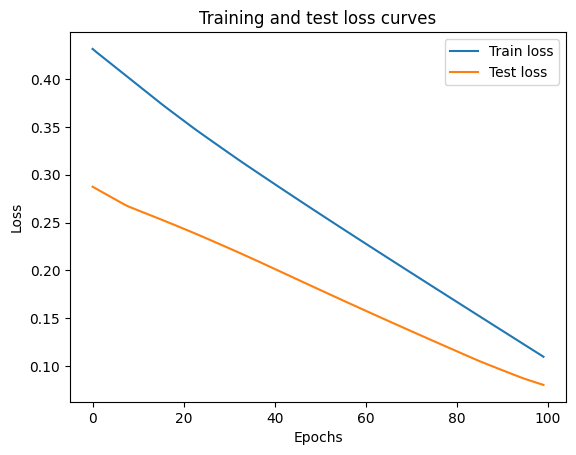

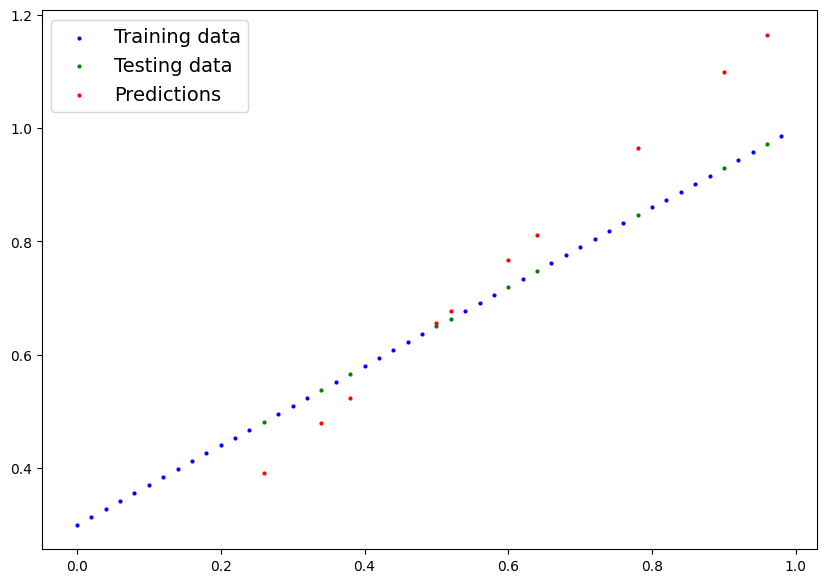

In [20]:
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs") # Zig Zag due to ADAM Optimizer
plt.legend()

model_0.eval()
# Make predictions using the testing data
with torch.inference_mode():
    y_preds_new = model_0(X_test)

# Plot the predictions
plot_predictions(predictions=y_preds_new)

In [21]:
# Saving a model in PyTorch
# 3 Methods
# 1: torch.save(): pickle format
# 2: torch.load(): load model
# 3: torch.nn.Module.load_state_dict(): allows to load models saved state dict

from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_SAVE_PATH = MODEL_PATH/ "model_0.pth"
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

loaded_model = LinearRegressionModel()# we'll copy params
loaded_model.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model.state_dict() == model_0.state_dict()

True

In [22]:
# Building using Linear Layers
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    # Use nn.Linear() to create model params
    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict(), next(model_1.parameters()).device # device alloc to specific tensor

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]),
 device(type='cpu'))

In [23]:
model_1.to(device) # set device
loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(params=model_1.parameters(),
                             lr=0.01)
torch.manual_seed(42)
epochs = 100

# convert to the required tensor for the device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)


for epoch in range(epochs):
  model_1.train();

  y_pred = model_1(X_train) #Forward pass

  loss = loss_fn(y_pred, y_train) # Calc loss

  optimizer.zero_grad() # Opt zero grad

  loss.backward() # backprop

  optimizer.step() # optm step

  # Testing
  model_1.eval()
  with torch.inference_mode():
    test_pred = model_1(X_test)
    test_loss = loss_fn(test_pred, y_test)
  if(epoch%10 ==0):
    print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")



Epoch: 0 | Loss: 0.5600506067276001 | Test Loss: 0.552076518535614
Epoch: 10 | Loss: 0.41350069642066956 | Test Loss: 0.39327675104141235
Epoch: 20 | Loss: 0.2669508755207062 | Test Loss: 0.23447687923908234
Epoch: 30 | Loss: 0.12043819576501846 | Test Loss: 0.079023577272892
Epoch: 40 | Loss: 0.08020032942295074 | Test Loss: 0.0650845617055893
Epoch: 50 | Loss: 0.07915192097425461 | Test Loss: 0.07089661061763763
Epoch: 60 | Loss: 0.06192823126912117 | Test Loss: 0.04720740765333176
Epoch: 70 | Loss: 0.048485610634088516 | Test Loss: 0.031831301748752594
Epoch: 80 | Loss: 0.03596453741192818 | Test Loss: 0.023197878152132034
Epoch: 90 | Loss: 0.02181817963719368 | Test Loss: 0.014690017327666283


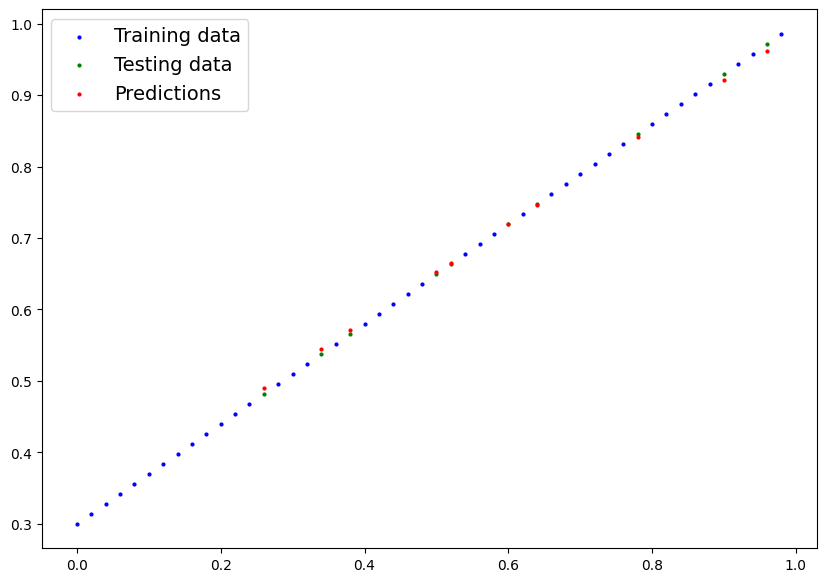

In [24]:
# Testing Model
model_1.eval()
with torch.inference_mode():
  y_preds = model_1(X_test)
plot_predictions(predictions=y_preds)

# Save and load this Model
#torch.save(obj=model_1.state_dict(), f=MODEL_SAVE_PATH)

(800, 200, 800, 200)

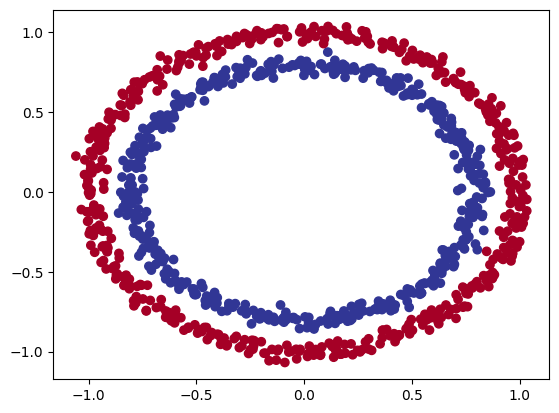

In [25]:
# Toy Dataset Generation
from sklearn.datasets import make_circles
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

n_samples = 1000
# Create circles
X , y = make_circles(n_samples,noise=0.03,random_state=42)
circles = pd.DataFrame({"X1": X[:, 0],
                        "X2": X[:, 1],
                       "label": y})
plt.scatter(x=X[:, 0], y=X[:, 1], c=y, cmap=plt.cm.RdYlBu)
X.shape, y.shape, X[0], y[0] # check I/O shape & samples

# convert to tensors
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)

In [26]:
# Building Model
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_pred))*100
  return acc

class BinaryClassificationModel(nn.Module):
  def __init__(self):
    super().__init__()
    #self.layer_1 = nn.Linear(in_features=2, out_features=8) # takes in 2 inputs features and outputs 8 features
    #self.layer_2 = nn.Linear(in_features=8, out_features=1) #input from above layer
    #self.sigmoid = nn.Sigmoid() # activation func
    # OR
    self.two_layer = nn.Sequential(
          nn.Linear(in_features=2, out_features=8),
          nn.ReLU(),
          nn.Linear(in_features=8, out_features=1)
          # Removed nn.ReLU() here as nn.BCEWithLogitsLoss expects raw logits
          # nn.Sigmoid() # not needed as BCEWithLogitsLoss has it built-in
      )

  def forward(self, x):
    #return self.sigmoid(self.layer_2(self.layer_1(x))); # x -> l1 ->l2
    return self.two_layer(x)

model_2 = BinaryClassificationModel()
#loss & optimizer
loss_fn = nn.BCEWithLogitsLoss() # has inbuild sigmoid func, BCELoss doesnt
optimizer = torch.optim.Adam(params=model_2.parameters(), lr=0.01)

model_2

BinaryClassificationModel(
  (two_layer): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [27]:
# Building Replication using nn.Sequential()
model_3 = nn.Sequential(
    nn.Linear(in_features=2, out_features=8),
    nn.Linear(in_features=8, out_features=1),
    nn.Sigmoid()
).to(device)
model_3

Sequential(
  (0): Linear(in_features=2, out_features=8, bias=True)
  (1): Linear(in_features=8, out_features=1, bias=True)
  (2): Sigmoid()
)

In [28]:
# the model will output raw logits
# so we convert them into probabilities using activation funcs
torch.manual_seed(42)

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  model_2.train()

  y_logits = model_2(X_train).squeeze() # forward pass
  y_pred = torch.round(torch.sigmoid(y_logits)) # logits->prob->label

  #loss = loss_fn(torch.sigmoid(y_logits), y_train) # the BCELoss expects probs
  loss = loss_fn(y_logits, y_train) # BCEWithLogitsLoss expects logits

  acc = accuracy_fn(y_train, y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_2.eval()
  with torch.inference_mode():
    #1. Forward pass
    test_logits = model_2(X_test).squeeze()
    test_pred =torch.round(torch.sigmoid(test_logits))
    #2. Calculate test loss/acc
    test_loss = loss_fn(test_logits, y_test)

  if epoch%10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss} | Acc: {acc} | Test Loss: {test_loss}")


Epoch: 0 | Loss: 0.6973499059677124 | Acc: 48.75 | Test Loss: 0.6890051364898682
Epoch: 10 | Loss: 0.6882284283638 | Acc: 52.37500000000001 | Test Loss: 0.6826838850975037
Epoch: 20 | Loss: 0.6815572381019592 | Acc: 52.125 | Test Loss: 0.6758821606636047
Epoch: 30 | Loss: 0.6745240688323975 | Acc: 57.125 | Test Loss: 0.6688660383224487
Epoch: 40 | Loss: 0.6639146208763123 | Acc: 66.0 | Test Loss: 0.6602950096130371
Epoch: 50 | Loss: 0.6500692963600159 | Acc: 76.0 | Test Loss: 0.6500294208526611
Epoch: 60 | Loss: 0.6332926750183105 | Acc: 87.875 | Test Loss: 0.6382245421409607
Epoch: 70 | Loss: 0.614433228969574 | Acc: 87.875 | Test Loss: 0.6235078573226929
Epoch: 80 | Loss: 0.5935727953910828 | Acc: 92.0 | Test Loss: 0.6052008271217346
Epoch: 90 | Loss: 0.5704771280288696 | Acc: 93.0 | Test Loss: 0.5830761194229126


In [29]:
from pathlib import Path
import requests

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

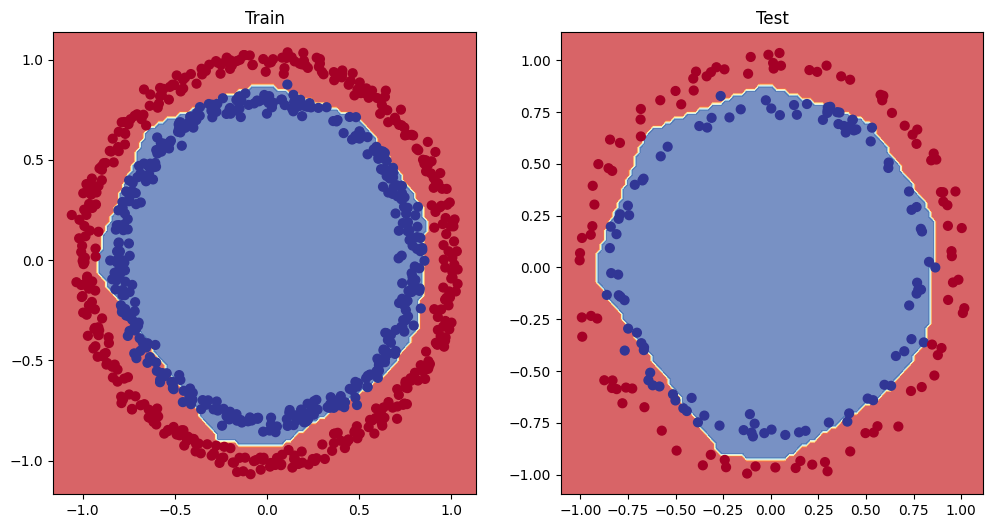

In [30]:
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_2, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_2, X_test, y_test)


# Improve model performace by:
1. increasing layers
2. increasing neurons in layers
3. change activation func.
4. train longer
5. change learning rate
6. change loss func.

In [31]:
def relu(x: torch.Tensor) -> torch.Tensor:
  return torch.maximum(torch.Tensor(0), x);
def sigmoid(x: torch.Tensor) -> torch.Tensor:
  return 1 / (1 + torch.exp(-x));

In [32]:
# Multi-Class Classification

# generate toy dataset & convert it into tensor and to train test split
from sklearn.datasets import make_blobs
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from torch import nn

# 1. Generate data
X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=2,
                            centers=4,
                            cluster_std=1.5,
                            random_state=42)

# 2. Convert to tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

# 3. Split into train and test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state=42)

# 4. Build model
class MultiClassClassification(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(in_features=2, out_features=16),
        nn.ReLU(),
        nn.Linear(in_features=16, out_features=8),
        nn.ReLU(),
        nn.Linear(in_features=8, out_features=4)
        # Note: We usually output raw logits and use nn.CrossEntropyLoss
    )

  def forward(self, x):
    return self.layers(x)

model_4 = MultiClassClassification().to(device)
print(model_4)

MultiClassClassification(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)


In [33]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_4.parameters(), lr=0.01)

torch.manual_seed(42)
epochs = 100

# Put data to target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    model_4.train()

    # 1. Forward pass
    y_logits = model_4(X_blob_train)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train, y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Testing
    model_4.eval()
    with torch.inference_mode():
        test_logits = model_4(X_blob_test)
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_true=y_blob_test, y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.33477, Acc: 49.25% | Test Loss: 1.27118, Test Acc: 60.50%
Epoch: 10 | Loss: 0.65881, Acc: 74.38% | Test Loss: 0.65529, Test Acc: 71.50%
Epoch: 20 | Loss: 0.18786, Acc: 99.00% | Test Loss: 0.16583, Test Acc: 99.50%
Epoch: 30 | Loss: 0.05180, Acc: 99.00% | Test Loss: 0.04439, Test Acc: 99.00%
Epoch: 40 | Loss: 0.03130, Acc: 99.12% | Test Loss: 0.02221, Test Acc: 99.50%
Epoch: 50 | Loss: 0.02746, Acc: 99.25% | Test Loss: 0.01593, Test Acc: 99.50%
Epoch: 60 | Loss: 0.02583, Acc: 99.25% | Test Loss: 0.01466, Test Acc: 99.50%
Epoch: 70 | Loss: 0.02513, Acc: 99.12% | Test Loss: 0.01400, Test Acc: 99.50%
Epoch: 80 | Loss: 0.02464, Acc: 99.12% | Test Loss: 0.01322, Test Acc: 99.50%
Epoch: 90 | Loss: 0.02424, Acc: 99.25% | Test Loss: 0.01264, Test Acc: 99.50%


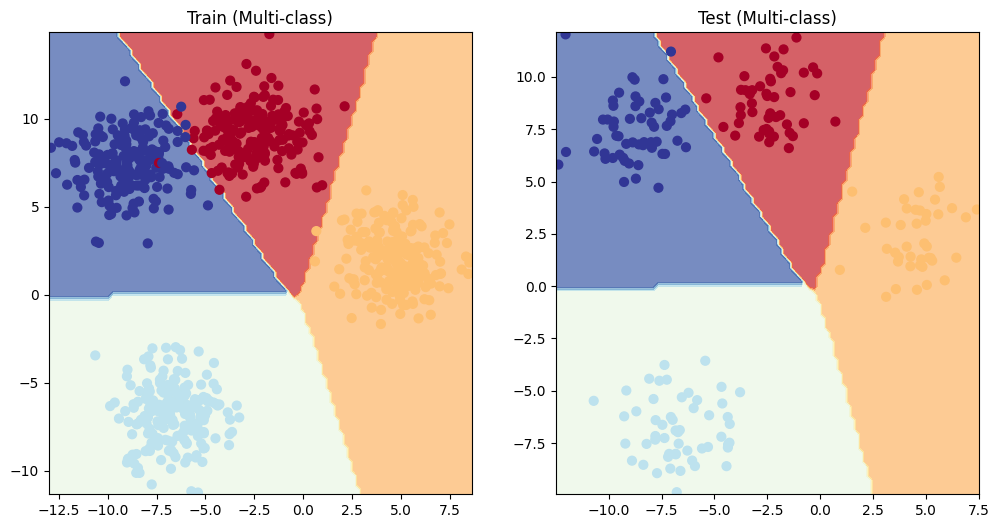

In [34]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train (Multi-class)")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test (Multi-class)")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

In [35]:
# Metrics: torchmetrics.Accuracy(), torchmetrics.Percision(), torchmetrics.Recall()
!pip install torchmetrics
from torchmetrics import Accuracy, Precision, Recall


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 15.8 MB/s eta 0:00:00


In [36]:
# Computer Vision: CNN
# torchvision.dataset : dataset and data loading func
# torchvision.models : get pretrained models
# torchvision.transform : function  for manipulating vision data
# torch.utils.data.Dataset : base dataset class for pytorch
# torch.utils.data.DataLoader : creates a python iterabe over a dataset

import torchvision # base lib for CV tasks
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 2.10.0+cpu
torchvision version: 0.25.0+cpu


In [37]:
# Data Loading
train_data = datasets.FashionMNIST(
    root="data", #downlod location
    train=True,
    download=True,
    transform=ToTensor(), # how do we want to transform data
    target_transform=None # how do we want to transform labels/targe
)
test_data = datasets.FashionMNIST(
    root="data",
    train=False, # we want testing one
    download=True,
    transform=ToTensor(),
    target_transform=None
)
print(len(train_data), len(test_data), train_data.classes)
print(train_data.class_to_idx, train_data.targets)


100%|██████████| 26.4M/26.4M [00:01<00:00, 18.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 315kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.67MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.2MB/s]

60000 10000 ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9} tensor([9, 0, 0,  ..., 3, 0, 5])


Label: 9, Class: Ankle boot


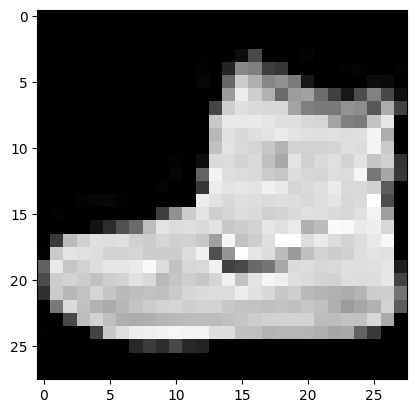

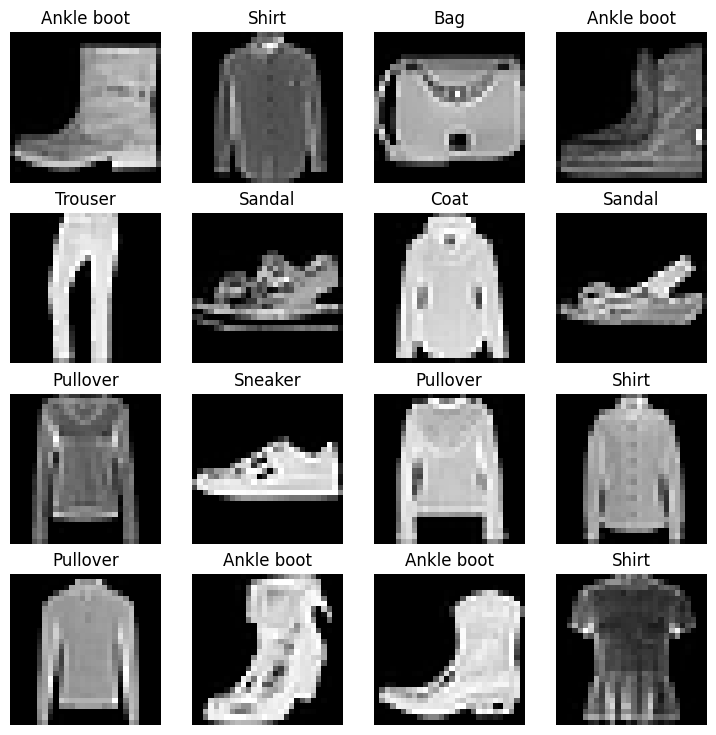

In [38]:
# Visualize the data
import matplotlib.pyplot as plt
image, label = train_data[0]
plt.imshow(image.squeeze(), cmap="gray") # squeez coz error due to 3rd dim
print(f"Label: {label}, Class: {train_data.classes[label]}")

class_name = train_data.classes
# random images
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows*cols+1):
  random_ix = torch.randint(0, len(train_data), size=[1]).item()
  image, label = train_data[random_ix]
  fig.add_subplot(rows, cols, i)
  plt.imshow(image.squeeze(), cmap="gray")
  plt.title(class_name[label])
  plt.axis(False)


In [39]:
# Prepare data i.e. convert into batches/mini-batches
# more computationally efficient & the memory usage not too high
# allows nn to more chances to update its gradient per epoch
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)


In [40]:
flatten_model = nn.Flatten() # h,w,colr -> colrs, h*w

class FashionMnistModel(nn.Module):
  def __init__(self, input_shape: int,
               hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape),
        nn.ReLU()
    )
  def forward(self, x):
    return self.layer_stack(x);

model_5 = FashionMnistModel(
    input_shape=28*28,
    hidden_units=10,
    output_shape=len(train_data.classes)
).to(device)


In [41]:
from tqdm.auto import tqdm
torch.manual_seed(42)

# Ensure optimizer and loss function are defined specifically for model_5
optimizer = torch.optim.Adam(params=model_5.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

for epoch in tqdm(range(3)): # Using 3 epochs for a quick fix
  print(f"Epoch: {epoch}\n---------")
  train_loss = 0
  model_5.train()
  for batch, (X, y) in enumerate(train_dataloader):
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model_5(X)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y)
    train_loss += loss

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    if batch % 400 == 0:
      print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

  train_loss /= len(train_dataloader)

  # Testing loop
  test_loss, test_acc = 0, 0
  model_5.eval()
  with torch.inference_mode():
    for X_test, y_test in test_dataloader:
      X_test, y_test = X_test.to(device), y_test.to(device)

      # 1. Forward pass (get logits)
      test_logits = model_5(X_test)

      # 2. Calculate loss (CrossEntropyLoss takes logits)
      test_loss += loss_fn(test_logits, y_test)

      # 3. Calculate accuracy
      test_pred = test_logits.argmax(dim=1)
      test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred)

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

  print(f"\nTrain Loss: {train_loss:.5f} | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train Loss: 0.63736 | Test Loss: 0.50035 | Test Acc: 82.83%
Epoch: 1
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train Loss: 0.49382 | Test Loss: 0.53026 | Test Acc: 81.86%
Epoch: 2
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train Loss: 0.47211 | Test Loss: 0.53718 | Test Acc: 81.62%


In [42]:
# Creating funcs for Training, Testing and Evaluation
def eval_model(model: nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: nn.Module,
               accuracy_fn):
    """Returns a dictionary containing the results of model predicting on data_loader."""
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": acc}

def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device):
    """Performs a single training step (one epoch) over a data_loader."""
    train_loss, train_acc = 0, 0
    model.train()
    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f}%")

def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device):
    """Performs a single testing step over a data_loader."""
    test_loss, test_acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            test_pred = model(X)
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%\n")


In [43]:
torch.manual_seed(42)

# Re-initialize the model to start training from scratch
model_5 = FashionMnistModel(
    input_shape=28*28,
    hidden_units=10,
    output_shape=len(train_data.classes)
).to(device)

# Setup loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_5.parameters(), lr=0.01)

# Set epochs
epochs = 3

# Create a training and testing loop using the functions
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(model=model_5,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device)
    test_step(model=model_5,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.63093 | Train acc: 77.79%
Test loss: 0.54821 | Test acc: 80.66%

Epoch: 1
---------
Train loss: 0.51536 | Train acc: 81.78%
Test loss: 0.53342 | Test acc: 81.50%

Epoch: 2
---------
Train loss: 0.49797 | Train acc: 82.51%
Test loss: 0.55850 | Test acc: 81.10%



In [44]:
# Final evaluation of model_5 using the modular eval_model function
model_5_results = eval_model(model=model_5,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)

print(f"Final Results: {model_5_results}")

Final Results: {'model_name': 'FashionMnistModel', 'model_loss': 0.5585033297538757, 'model_acc': 81.10023961661342}


In [45]:
# Building CNN Model with Dropout
class CNN(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape, dropout_rate=0.2):
    super().__init__()
    self.cnn_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),
        nn.Dropout(dropout_rate)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),
        nn.Dropout(dropout_rate)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
    )

  def forward(self, x):
    x = self.cnn_block_1(x)
    x = self.conv_block_2(x)
    x = self.classifier(x)
    return x

torch.manual_seed(42)
model_6 = CNN(input_shape=1, hidden_units=10, output_shape=len(train_data.classes)).to(device)

In [46]:
torch.manual_seed(42)

# Re-initialize model_6 with the new Dropout architecture
model_6 = CNN(input_shape=1, hidden_units=10, output_shape=len(train_data.classes)).to(device)

# Setup loss and optimizer for model_6
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_6.parameters(), lr=0.001)

# Set the number of epochs
epochs = 5

# Training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
               model=model_6,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device
    )
    test_step(data_loader=test_dataloader,
              model=model_6,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device
    )

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.59944 | Train acc: 77.85%
Test loss: 0.43552 | Test acc: 84.97%

Epoch: 1
---------
Train loss: 0.41932 | Train acc: 84.76%
Test loss: 0.37774 | Test acc: 86.44%

Epoch: 2
---------
Train loss: 0.38100 | Train acc: 86.09%
Test loss: 0.35869 | Test acc: 86.72%

Epoch: 3
---------
Train loss: 0.35866 | Train acc: 86.78%
Test loss: 0.33027 | Test acc: 88.31%

Epoch: 4
---------
Train loss: 0.34137 | Train acc: 87.56%
Test loss: 0.31958 | Test acc: 88.48%



In [47]:
# Evaluate the CNN model (with Dropout) and compare results
model_6_results = eval_model(
    model=model_6,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

print(f"CNN (with Dropout) Results: {model_6_results}")
print(f"Previous Linear Model Results: {model_5_results}")

CNN (with Dropout) Results: {'model_name': 'CNN', 'model_loss': 0.31957828998565674, 'model_acc': 88.47843450479233}
Previous Linear Model Results: {'model_name': 'FashionMnistModel', 'model_loss': 0.5585033297538757, 'model_acc': 81.10023961661342}


In [48]:
!pip install torchmetrics mlxtend
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

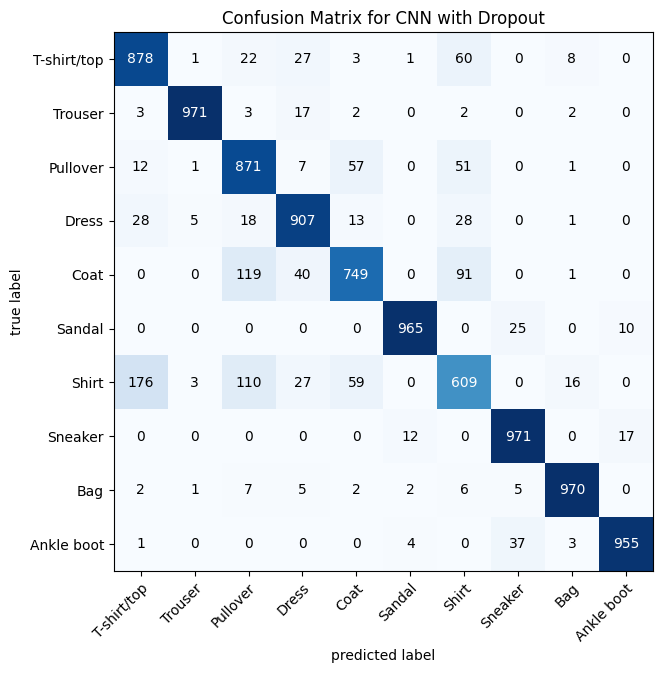

In [49]:
# 1. Make predictions with trained model
y_preds = []
model_6.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    X, y = X.to(device), y.to(device)
    y_logit = model_6(X)
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)
    y_preds.append(y_pred.cpu())

# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)

# 2. Setup confusion matrix instance and compare predictions to targets
# Note: Ensure class_name is available from earlier cells
confmat = ConfusionMatrix(num_classes=len(class_name), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# 3. Plot the confusion matrix using mlxtend
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_name,
    figsize=(10, 7)
)
plt.title("Confusion Matrix for CNN with Dropout")
plt.show()

In [49]:
# Importing Our/Custom Dataset
from pathlib import Path

data_path = Path('data/')
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
  print(f"{image_path} already exists")
else:
  print(f"{image_path} does not exist creating one")
  image_path.mkdir(parents=True, exist_ok=True)

with open(data_path/"pizza_steak_sushi.sip", "wb") as f:
  request = request.get("URL")
  f.write(request.content)

with zipfile.ZipFile(data_path/"pizza_steak_sushi.sip", "r") as zip_ref:
  zip_ref.extractall(image_path)



In [ ]:
import os
train_dir = image_path / "train"
test_dir = image_path / "test"

def walk_through_dir(dir_path):
  """ Walk through dir_path returning its contents."""
  for dirpath, dirname, filename in os.walk(dir_path):
    print(f" there are {len(dirname)}")


In [ ]:
import random
from PIL import Image
random.seed(42)

image_path_list = list(image_path.glob("*/*.jpg"))
img = Image.open(image_path_list[random.randint(0, len(image_path_list))])
img.show(img)

import numpy as np
import matplotlib.pyplot as plt

img_as_arry = np.asarray(img)
plt.imshow(img_as_arry)
plt.axis(False)


In [51]:
# Transforming data
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image
from typing import Tuple, Dict, List

# custom data transform
data_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])
# Dataset with tranformation settings
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transforms,
                                  target_transform=None)
test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transforms,
                                 target_transform=None)
class_names = train_data.classes

img_permute = img.premute(1, 2, 0)

# create dataloader
train_dataLoader = DataLoader(dataset=train_data,
                              batch_size=32,
                              shuffle=True,
                              num_workers=os.cpu_count())
test_dataLoader = DataLoader(dataset=test_data,
                             batch_size=32,
                             shuffle=False,
                             num_workers=os.cpu_count())

#

In [53]:
# Data Augumentation : adding variety to the dataset by shiting, rotating, zooming etc.
from torchvision import transforms
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)), # Resizes the image to 64x64 pixels
    transforms.RandomHorizontalFlip(p=0.5), # Randomly flips the image horizontally with a probability of 0.5
    transforms.RandomRotation(degrees=15), # Randomly rotates the image by up to 15 degrees
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1), # Randomly changes the brightness, contrast, saturation, and hue of the image
    transforms.ToTensor(), # Converts the image to a PyTorch tensor (HWC to CHW, 0-255 to 0-1)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # Normalizes the tensor with a given mean and standard deviation
                         std=[0.229, 0.224, 0.225]) # These are common values for ImageNet-trained models
])

In [54]:
class tinyVGG(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        # Input image 64x64 -> conv_block_1 (MaxPool) -> 32x32 -> conv_block_2 (MaxPool) -> 16x16
        nn.Linear(in_features=hidden_units*16*16,
                  out_features=output_shape)
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    return self.classifier(x)

torch.manual_seed(42)
model_7 = tinyVGG(input_shape=1, # Changed to 1 channel for FashionMNIST
                  hidden_units=10, output_shape=len(train_data.classes)).to(device)

In [55]:
!pip install torchinfo

In [56]:
from torchinfo import summary

# Print a summary of the model
summary(model_7, input_size=[1, 1, 64, 64]) # Batch size of 1, 1 color channel, 64x64 image

Layer (type:depth-idx)                   Output Shape              Param #
tinyVGG                                  [1, 10]                   --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           100
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

In [ ]:
# Setup loss function and optimizer for model_7
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_7.parameters(), lr=0.001)

# Setup learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1) # Decays the learning rate by a factor of 0.1 every 30 epochs

# Set the number of epochs
epochs = 5

print(f"Training {model_7.__class__.__name__} for {epochs} epochs...")

# Training and testing loop for model_7
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(
        data_loader=train_dataloader,
        model=model_7,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(
        data_loader=test_dataloader,
        model=model_7,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )
    scheduler.step() # Update the learning rate after each epoch
print("Training complete!")

In [ ]:
# Evaluate the tinyVGG model and compare results
model_7_results = eval_model(
    model=model_7,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

print(f"tinyVGG Model Results: {model_7_results}")
print(f"CNN (with Dropout) Results: {model_6_results}")
print(f"Previous Linear Model Results: {model_5_results}")